# 🚲 Cyclistic Bike-Share User Behavior Analysis

## 1. Business Problem

### Project Overview

Cyclistic is a bike-share company serving customers across Chicago. Its riders are primarily divided into two groups:

* **Casual riders** — customers using single-ride or short-term passes
* **Annual members** — customers with annual memberships

This project analyzes historical bike-share trip data to understand how these two customer segments use the service differently.

### Business Question

> **How do casual riders and annual members use Cyclistic bikes differently, and what behavioral patterns could help identify opportunities for membership growth?**

### Analytical Objectives

The analysis focuses on the following dimensions:

* **Ride volume:** Compare the number of rides taken by each customer segment.
* **Time patterns:** Analyze usage by day of the week, month, season, and hour.
* **Ride duration:** Compare how long casual riders and members typically use bikes.
* **Bike preferences:** Examine differences in bike-type usage.
* **Station behavior:** Identify frequently used starting stations for each customer segment.
* **Geographic patterns:** Explore differences in where casual riders and members tend to start their trips.

### Analytical Approach

The project uses **Python and pandas** for data cleaning and exploratory analysis, with visualizations used to identify behavioral patterns and segment differences.

The analysis follows a typical data analytics workflow:

**Data Cleaning → Exploratory Data Analysis → Customer Segmentation → Behavioral Insights → Business Recommendations**

### Expected Business Value

By identifying clear differences between casual riders and annual members, this analysis aims to provide **data-driven insights that can support customer segmentation and membership growth strategies**.

## 2. Data Understanding

### Dataset Overview

This analysis uses Cyclistic bike-share trip data covering **12 months from January to December 2025**.

The dataset consists of **12 CSV files**, with each file containing bike-share trip records for one month of 2025. The monthly datasets are combined into a single dataset for analysis.

Each row represents an individual bike-share ride and contains information about the ride, including the bike type, start and end times, user type, and geographic locations.

### Data Structure

The main variables included in the dataset are:

| Variable             | Description                               |
| -------------------- | ----------------------------------------- |
| `ride_id`            | Unique identifier for each ride           |
| `rideable_type`      | Type of bike used for the ride            |
| `started_at`         | Date and time when the ride started       |
| `ended_at`           | Date and time when the ride ended         |
| `start_station_name` | Name of the starting station              |
| `start_station_id`   | Unique identifier of the starting station |
| `end_station_name`   | Name of the ending station                |
| `end_station_id`     | Unique identifier of the ending station   |
| `start_lat`          | Latitude of the starting location         |
| `start_lng`          | Longitude of the starting location        |
| `end_lat`            | Latitude of the ending location           |
| `end_lng`            | Longitude of the ending location          |
| `member_casual`      | User type: casual or member               |

### Time Period

The dataset covers the complete **2025 calendar year**, from **January through December**.

Having a full year of data allows the analysis to examine changes in riding behavior across different time periods, including:

* Monthly riding patterns
* Day-of-week patterns
* Hourly riding patterns
* Seasonal changes
* Ride duration

### Key Analysis Dimensions

The analysis focuses on the following dimensions:

1. **User type** – casual riders vs. annual members
2. **Bike type** – types of bikes used
3. **Time** – month, day of the week, and hour of the day
4. **Ride duration** – how long each ride lasts
5. **Station usage** – frequently used starting stations
6. **Geographic patterns** – starting and ending locations

### Data Understanding Goal

The purpose of this stage is to understand the structure, variables, and time coverage of the dataset before performing data cleaning and exploratory analysis.

The 12 monthly CSV files will be combined into a single dataset so that riding behavior can be analyzed consistently across the entire year.

# Import Libraries

In [60]:
# Importing Data Science Libraries
import numpy as np
import pandas as pd
import os

# Importing Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import plotly.offline as pyo
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Importing Mapping Library
import folium

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import Datasets

In [61]:
# Set the dataset path
dataset_path = '/kaggle/input/datasets/tiali10/cyclistic-bike-share-analysis-case-study/'

# Store the monthly datasets
dataframes = []

# Read all CSV files
for fname in os.listdir(dataset_path):
    if fname.endswith('.csv'):
        filepath = os.path.join(dataset_path, fname)
        df = pd.read_csv(filepath)
        dataframes.append(df)

# Combine all 12 monthly datasets
merged_df = pd.concat(dataframes, ignore_index=True)

# Display the first five rows
merged_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,LF-005,Winthrop Ave & Lawrence Ave,TA1308000021,41.911722,-87.626804,41.968812,-87.657659,member
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,TA1308000006,Desplaines St & Jackson Blvd,15539,41.892394,-87.676885,41.878119,-87.643948,member
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,13430,Clark St & Elm St,TA1307000039,41.890762,-87.631697,41.903322,-87.632999,member
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,13242,Damen Ave & Cortland St,13133,41.920330,-87.693090,41.915983,-87.677335,member
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,TA1305000017,Clinton St & Roosevelt Rd,WL-008,41.867324,-87.648625,41.867118,-87.641088,member


## 3. Data Cleaning

Before conducting the analysis, the raw datasets were cleaned to improve data quality and ensure that the data was suitable for further analysis.
### 3.1 Missing Values

Missing values were examined to assess the completeness of the dataset before further analysis.

The percentage of missing values was calculated for each column. Columns with no missing values were excluded from the visualization to make the chart easier to interpret.

The results are shown below:

*Figure: Percentage of Missing Values by Column*

The visualization helps identify which variables contain missing values and the extent of missingness. These missing values were then handled based on the importance and nature of each variable.


In [62]:
# Calculate the percentage of missing values in each column
missing_pct = merged_df.isnull().mean() * 100

# Keep only columns that contain missing values
missing_pct = missing_pct[missing_pct > 0]

# Convert the Series into a DataFrame
missing_summary = missing_pct.reset_index()

# Rename the columns
missing_summary.columns = ['Column', 'Missing Percentage']

# Create a bar chart to visualize missing values
fig = px.bar(
    missing_summary,
    x='Column',
    y='Missing Percentage',
    title='Percentage of Missing Values by Column',
    labels={
        'Column': 'Column',
        'Missing Percentage': 'Missing Values (%)'
    }
)

fig.show()


### Key Observation

The visualization shows that missing values are mainly concentrated in station-related and geographic variables.

* **`start_station_name`** and **`start_station_id`** have the same missing rate of approximately **21.33%**.
* **`end_station_name`** and **`end_station_id`** have the same missing rate of approximately **22.39%**.
* **`end_lat`** and **`end_lng`** also have the same missing rate of approximately **0.0997%**.

The identical missing rates within each pair suggest that these variables may be missing together rather than independently. This pattern is important to consider when deciding how to handle missing values during the data-cleaning process.


In [63]:
# Check whether each pair of related variables has the same missing-value pattern

print((merged_df['start_station_name'].isnull() == merged_df['start_station_id'].isnull()).all())

print((merged_df['end_station_name'].isnull() == merged_df['end_station_id'].isnull()).all())

print((merged_df['end_lat'].isnull() == merged_df['end_lng'].isnull()).all())


True
True
True


### Missing Value Pattern Check

The results of the missing-value pattern check are all **True**.

This confirms that:

* `start_station_name` and `start_station_id` have the same missing-value pattern.
* `end_station_name` and `end_station_id` have the same missing-value pattern.
* `end_lat` and `end_lng` have the same missing-value pattern.

Therefore, the missing values within each related pair occur in the same rows rather than independently. This pattern was considered when deciding how to handle missing values during the data-cleaning process.


### 3.2 Missing Value Treatment

The missing-value analysis showed that `start_station_name` and `start_station_id` have the same missing pattern, while `end_station_name` and `end_station_id` also have the same missing pattern.

Similarly, `end_lat` and `end_lng` have the same missing pattern, with only approximately **0.0997%** of values missing.

Based on these findings, the missing values were handled as follows:

| Missing Variable     | Handling Method                 |
| -------------------- | ------------------------------- |
| `start_station_name` | Missing → `Not Available`       |
| `start_station_id`   | Missing → `Not Available`       |
| `end_station_name`   | Missing → `Not Available`       |
| `end_station_id`     | Missing → `Not Available`       |
| `end_lat`            | Remove rows with missing values |
| `end_lng`            | Remove rows with missing values |

The station-related fields were retained by replacing missing values with `Unknown`. Since the missing proportion of `end_lat` and `end_lng` is very small, rows with missing geographic coordinates were removed to ensure complete coordinate information for distance and geographic analysis.


In [64]:
# Replace missing station information with "Not Available"
merged_df['start_station_name'].fillna('Not Available', inplace=True)
merged_df['start_station_id'].fillna('Not Available', inplace=True)

merged_df['end_station_name'].fillna('Not Available', inplace=True)
merged_df['end_station_id'].fillna('Not Available', inplace=True)


# Remove rows with missing end coordinates
merged_df.dropna(
    subset=['end_lat', 'end_lng'],
    inplace=True
)

### 3.3 Convert Date and Time Columns

The `started_at` and `ended_at` columns contain date and time information. To perform time-based analysis, these columns were converted from strings to the **datetime** data type.

The `dtypes` output was used to verify that `started_at` and `ended_at` were successfully converted to the `datetime64[ns]` data type.

This conversion allows the dataset to support time-based analysis, such as extracting the **month, day of the week, and hour** from each ride.


In [65]:
print(merged_df.dtypes)

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object


In [66]:
def clean_trip_data(df):
    df['started_at'] = pd.to_datetime(df['started_at'])
    df['ended_at'] = pd.to_datetime(df['ended_at'])
    
    df['start_station_id'] = df['start_station_id'].astype(str)
    df['end_station_id'] = df['end_station_id'].astype(str)
    
    df.drop_duplicates(inplace=True)
    
    return df

merged_df = clean_trip_data(merged_df)


In [67]:
print(merged_df.dtypes)

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
dtype: object


### 3.4 Remove Duplicate Records
Duplicate rows were identified and removed using drop_duplicates().
Removing duplicates helps prevent the same ride from being counted more than once and improves the accuracy of subsequent analysis.

In [68]:
merged_df.drop_duplicates(inplace=True)

### 3.5 Verify Missing Values After Cleaning

After handling the missing values, the missing data matrix was plotted again to verify the results.

<Axes: >

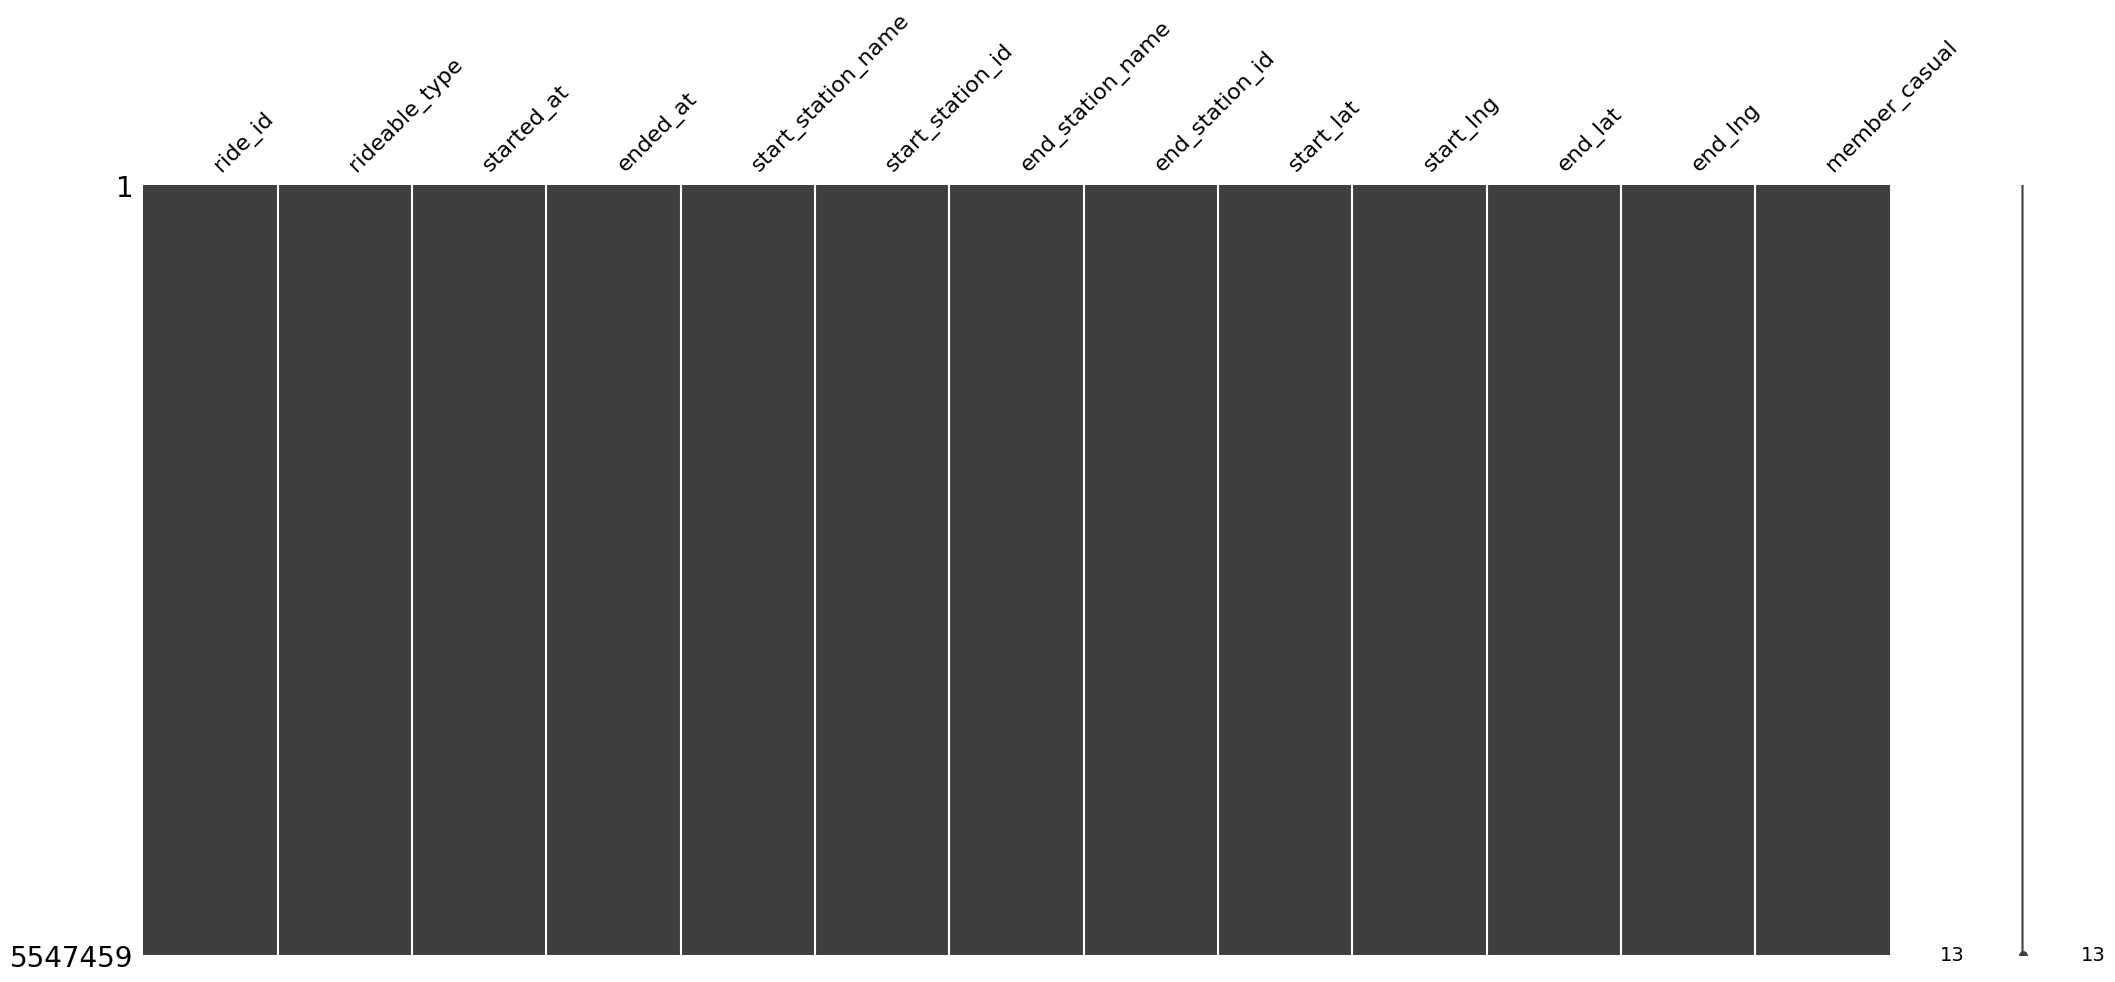

In [69]:
# Check the distribution of missing values after cleaning
msno.matrix(merged_df)

The visualization shows that there are **no remaining missing values** in the dataset after the cleaning process. This confirms that the missing-value treatment was successfully applied.

## 4. Feature Engineering

Feature engineering was performed to create additional variables that could provide more useful insights into riding behavior.

The original dataset contains raw information such as ride start and end times and geographic coordinates. These variables were transformed into more meaningful features for analysis.

The following features were created:

* **Ride length** – the duration of each ride in minutes
* **Day of week** – the day on which the ride started
* **Hour** – the hour when the ride started
* **Month** – the month when the ride started
* **Year** – the year when the ride started
* **Ride length category** – groups rides into different duration ranges
* **Distance** – the approximate straight-line distance between the start and end locations, calculated using the Haversine formula, in kilometers
* **Distance category** – groups rides into different distance ranges

These features allow riding behavior to be analyzed across different time periods, ride durations, and geographic distances.


### 4.1 Calculate Ride Length
Ride length was calculated as the difference between the ride end time and start time.

The result was converted from seconds to minutes to make the variable easier to interpret.

This feature will be used to compare ride durations between casual riders and annual members.

In [70]:
df = merged_df
# Calculate ride length in minutes by subtracting the start time from the end time
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

### 4.2 Extract Time Features

Several time-based features were extracted from the `started_at` column.

* `day_of_week` identifies the day of the week when the ride started.
* `hour` identifies the hour of the day when the ride started.
* `month` identifies the month when the ride started.
* `year` identifies the year when the ride started.

These features allow the analysis to identify **daily, hourly, monthly, and seasonal riding patterns**.


In [71]:
# Extract the day of the week from the ride start time
df['day_of_week'] = df['started_at'].dt.dayofweek + 1

# Extract the hour of the day from the ride start time
df['hour'] = df['started_at'].dt.hour

# Extract the month from the ride start time
df['month'] = df['started_at'].dt.month

# Extract the year from the ride start time
df['year'] = df['started_at'].dt.year

### 4.3 Create Ride Length Categories

Descriptive statistics showed that most rides were relatively short, with a median ride length of approximately 9.4 minutes. Based on the distribution, ride lengths were grouped into several categories, using smaller intervals for shorter rides and broader intervals for longer rides.

These categories make it easier to compare ride-duration patterns between casual riders and annual members.


### Check Ride Length

In [72]:
# Check summary statistics for ride length
df['ride_length'].describe()

count    5.547459e+06
mean     1.457352e+01
std      2.977862e+01
min     -5.479480e+01
25%      5.391483e+00
50%      9.416633e+00
75%      1.653006e+01
max      1.499968e+03
Name: ride_length, dtype: float64



The descriptive statistics showed negative values in `ride_length`, which are invalid because ride duration cannot be negative. Negative `ride_length` values were identified as invalid records and will be removed from the dataset before further analysis.



In [73]:
# Remove records with negative or zero ride lengths
df = df[df['ride_length'] > 0]

# Check the ride length distribution after removing invalid values
df['ride_length'].describe()

count    5.547430e+06
mean     1.457382e+01
std      2.977840e+01
min      7.666667e-04
25%      5.391521e+00
50%      9.416683e+00
75%      1.653011e+01
max      1.499968e+03
Name: ride_length, dtype: float64

Descriptive statistics showed that most rides were relatively short, with a median ride length of approximately 9.4 minutes. Based on the distribution, ride lengths were grouped into several categories, using smaller intervals for shorter rides and broader intervals for longer rides.

In [74]:
# Define the boundaries for ride length categories in minutes
bins = [0, 5, 10, 15, 20, 30, 45, 60, np.inf]

# Define labels for each ride length category
labels = ['0-5', '5-10', '10-15', '15-20','20-30', '30-45', '45-60', '60+']

# Categorize each ride based on its ride length
df['ride_length_category'] = pd.cut(
    df['ride_length'],
    bins=bins,
    labels=labels
)


### 4.4 Calculate Distance

The approximate distance between the starting and ending locations was calculated using the **Haversine formula**.

The calculation uses the latitude and longitude of the start and end locations to estimate the **straight-line distance** between the two points.

The resulting `distance_km` feature represents the approximate distance in kilometers. It does not represent the actual road distance traveled by the rider.

This feature will be used to examine geographic differences in riding behavior between casual riders and annual members.


In [75]:
# Import functions for Haversine distance calculation
from math import radians, cos, sin, sqrt, atan2


# Define a function to calculate the straight-line distance
def calculate_haversine_distance(row):

    # Define the Earth's radius in kilometers
    earth_radius_km = 6371.0

    # Convert the starting latitude from degrees to radians
    lat_start = radians(row['start_lat'])

    # Convert the starting longitude from degrees to radians
    lon_start = radians(row['start_lng'])

    # Convert the ending latitude from degrees to radians
    lat_end = radians(row['end_lat'])

    # Convert the ending longitude from degrees to radians
    lon_end = radians(row['end_lng'])

    # Calculate the difference in latitude
    delta_lat = lat_end - lat_start

    # Calculate the difference in longitude
    delta_lon = lon_end - lon_start

    # Apply the Haversine formula
    haversine_value = (
        sin(delta_lat / 2)**2
        + cos(lat_start) * cos(lat_end) * sin(delta_lon / 2)**2
    )

    # Calculate the angular distance
    angular_distance = 2 * atan2(
        sqrt(haversine_value),
        sqrt(1 - haversine_value)
    )

    # Calculate the straight-line distance in kilometers
    distance_value_km = earth_radius_km * angular_distance

    return distance_value_km

In [76]:
df['ride_distance_km'] = df.apply(
    calculate_haversine_distance,
    axis=1
)

### 4.5 Create Distance Categories

The calculated distances were grouped into several categories, ranging from less than 1 kilometer to more than 5 kilometers.

These categories make it easier to analyze the distribution of short and long rides and visualize differences in riding distance between casual riders and annual members.


In [77]:
# Check summary statistics for ride distance
df['ride_distance_km'].describe()

count    5.547430e+06
mean     2.202802e+00
std      1.994844e+00
min      0.000000e+00
25%      9.081145e-01
50%      1.615363e+00
75%      2.879212e+00
max      4.056503e+01
Name: ride_distance_km, dtype: float64

Descriptive statistics showed that most rides covered relatively short distances, with a median distance of approximately 1.6 km and 75% of rides below 2.9 km. Based on the distribution, ride distances were grouped into several categories, using smaller intervals for shorter distances and broader intervals for longer distances.

In [78]:
# Define the boundaries for distance categories in kilometers
bins = [0, 0.5, 1, 2, 3, 5, 10, np.inf]

# Define labels for each distance category
labels = ['0-0.5','0.5-1','1-2','2-3','3-5','5-10','10+']

# Categorize each ride based on its calculated distance
df['ride_distance_category'] = pd.cut(
    df['ride_distance_km'],
    bins=bins,
    labels=labels
)

In [79]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_length,day_of_week,hour,month,year,ride_length_category,ride_distance_km,ride_distance_category
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,LF-005,Winthrop Ave & Lawrence Ave,TA1308000021,41.911722,-87.626804,...,-87.657659,member,48.662967,7,17,5,2025,45-60,6.841902,5-10
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,TA1308000006,Desplaines St & Jackson Blvd,15539,41.892394,-87.676885,...,-87.643948,member,9.971633,1,8,5,2025,5-10,3.155062,3-5
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,13430,Clark St & Elm St,TA1307000039,41.890762,-87.631697,...,-87.632999,member,6.570000,5,10,5,2025,5-10,1.400717,1-2
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,13242,Damen Ave & Cortland St,13133,41.920330,-87.693090,...,-87.677335,member,5.142450,1,11,5,2025,5-10,1.390301,1-2
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,TA1305000017,Clinton St & Roosevelt Rd,WL-008,41.867324,-87.648625,...,-87.641088,member,4.062117,4,10,5,2025,0-5,0.624534,0.5-1


## 5. Exploratory Data Analysis

Exploratory data analysis was conducted to examine riding patterns and identify differences between casual riders and annual members.

The analysis focuses on ride volume, time patterns, ride length, distance, bike type, and station usage.


### 5.1 User Type Distribution

The first step of the exploratory analysis was to examine the distribution of rides between **casual riders** and **annual members**.

The total number of rides for each user type was calculated and visualized using a bar chart. This comparison provides an initial understanding of how ride activity is distributed across the two customer groups.


In [80]:
# Count the number of rides for each user type
user_type_summary = (
    df['member_casual']
    .value_counts()
    .reset_index()
)

# Rename the columns
user_type_summary.columns = ['User Type', 'Ride Count']

# Define consistent colors for each user type
# These colors are selected to be more accessible for people with color vision deficiencies
user_colors = {
    'member': '#0072B2',
    'casual': '#E69F00'
}
# Create a bar chart to compare ride counts
fig = px.bar(
    user_type_summary,
    x='User Type',
    y='Ride Count',
    color='User Type',
    color_discrete_map=user_colors,
    title='Number of Rides by User Type'
)

# Display the chart
fig.show()

The results show that **annual members made approximately 3.55 million rides**, while **casual riders made approximately 1.99 million rides** during the study period.

This indicates that **annual members accounted for a larger share of total rides than casual riders**. Further analysis will examine how the two user groups differ in terms of **day of the week, time of day, ride duration, distance, and bike type**.


### 5.2 Ride Volume by Day of Week

The analysis examined how ride volume varied across the days of the week for **casual riders** and **annual members**.

The number of rides was grouped by user type and day of the week. A grouped bar chart was used to compare riding activity between the two user groups from Monday to Sunday.

This analysis helps identify differences in weekly riding patterns and determine whether casual riders and annual members tend to use the bike-share service more frequently on weekdays or weekends.


In [81]:
# Define the order of the days of the week
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]


# Convert the numeric day of the week into day names
df['day_name'] = df['day_of_week'].map({
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
})


# Count the number of rides for each user type and day of the week
day_summary = (
    df.groupby(['day_name', 'member_casual'])
      .size()
      .reset_index(name='Ride Count')
)


# Set the day of the week as an ordered categorical variable
day_summary['day_name'] = pd.Categorical(
    day_summary['day_name'],
    categories=day_order,
    ordered=True
)

# Sort the results according to the order of the week
day_summary = day_summary.sort_values('day_name')

# Display the summary table
day_summary

,day_name,member_casual,Ride Count
2,Monday,casual,227743
3,Monday,member,502656
10,Tuesday,casual,225159
11,Tuesday,member,562961
12,Wednesday,casual,221100
13,Wednesday,member,550023
8,Thursday,casual,257521
9,Thursday,member,575861
0,Friday,casual,319291
1,Friday,member,528856


In [82]:
# Create a grouped bar chart to compare ride volume by day of the week
fig = px.bar(
    day_summary,
    x='day_name',
    y='Ride Count',
    color='member_casual',
    barmode='group',
    color_discrete_map=user_colors,
    category_orders={
        'day_name': day_order
    },
    title='Number of Rides by Day of the Week and User Type',
    labels={
        'day_name': 'Day of the Week',
        'Ride Count': 'Number of Rides',
        'member_casual': 'User Type'
    },
    text='Ride Count'      
)

# Format the numbers displayed above the bars
fig.update_traces(
    texttemplate='%{text:,}',  
    textposition='outside'     
)

# Display the chart
fig.show()

The chart compares ride volume between **casual riders** and **annual members** across the seven days of the week.

### Key Findings

* **Annual members** recorded higher ride volumes across most weekdays, with particularly strong activity from **Tuesday to Thursday**.
* Member ride volume decreased toward the weekend, with **Sunday recording the lowest level** among the seven days.
* **Casual riders** showed relatively lower activity during most weekdays but increased toward the weekend.
* **Saturday recorded the highest casual ride volume**, while Sunday also showed relatively strong activity.
* The two customer segments therefore show different weekly usage patterns, with members more concentrated on weekdays and casual riders more active on weekends.

### Business Insight

The difference in weekday and weekend activity suggests that **annual members and casual riders have different usage patterns**. However, ride volume alone cannot establish the underlying purpose of a trip, so additional analysis of **ride duration, time of day, station location, and seasonality** is needed to better understand these behaviors.

### Business Opportunities 
1. **Casual Rider Conversion** Weekends represent an important opportunity to engage casual riders because their ride volume is particularly high on Saturday and Sunday. Cyclistic could consider targeted weekend marketing campaigns, such as membership promotions, in-app messages, or offers at popular stations, to encourage frequent casual riders to consider annual memberships.
2. **Member Engagement** Since annual members have relatively high weekday usage, Cyclistic could introduce weekend-focused member activities or incentives to encourage additional usage during non-workdays.

### 5.3 Ride Volume by Hour

This analysis helps identify the most common riding hours and determine whether casual riders and annual members show different patterns throughout the day.


In [83]:
# Count the number of rides for each hour and user type
hour_summary = (
    df.groupby(['hour', 'member_casual'])
      .size()
      .reset_index(name='Ride Count')
)

# Display the summary table
hour_summary

,hour,member_casual,Ride Count
0,0,casual,38848
1,0,member,32451
2,1,casual,24888
3,1,member,19975
4,2,casual,16634
5,2,member,12007
6,3,casual,9187
7,3,member,7942
8,4,casual,7270
9,4,member,8878


In [84]:
# Create a grouped bar chart to compare ride volume by hour
fig = px.bar(
    hour_summary,
    x='hour',
    y='Ride Count',
    color='member_casual',
    barmode='group',
    color_discrete_map=user_colors,
    title='Number of Rides by Hour and User Type',
    labels={
        'hour': 'Hour of Day',
        'Ride Count': 'Number of Rides',
        'member_casual': 'User Type'
    },
)

# Display the chart
fig.show()

### Annual Member Patterns

* Annual members show a clear **two-peak pattern** during the day.
* The first major peak occurs at approximately **8:00 AM**, with around **250K rides**.
* The highest peak occurs at approximately **5:00 PM**, reaching nearly **380K rides**.
* Ride volume is more concentrated around these peak hours compared with casual riders.
* The concentration during morning and afternoon peak periods may be consistent with regular commuting or routine travel, although trip purpose is not directly recorded in the dataset.

### Casual Rider Patterns

* Casual riders do not show a strong morning peak around **8:00 AM**.
* Ride volume begins to increase from approximately **10:00 AM** and reaches its highest level between **4:00 PM and 5:00 PM**, at close to **200K rides**.
* Ride volume remains relatively high throughout the evening and declines more gradually than for annual members.
* Compared with annual members, casual riders show a more **distributed riding pattern across the afternoon and evening**.

### Key Business Insights

The hourly analysis highlights clear differences in usage patterns between the two user groups:

* **Annual members** have stronger concentrations around morning and evening peak hours.
* **Casual riders** are more active during the afternoon and early evening.
* The different hourly patterns suggest that the two segments may have different usage needs and behavioral patterns.

### Business Implications

1. **Operational Planning**

   Cyclistic could monitor bike availability around the major member demand periods, particularly **8:00 AM and 5:00 PM**, especially at stations with consistently high ride volume.

2. **Casual Rider Engagement**

   The afternoon and early evening represent important usage windows for casual riders. These periods could be considered when designing and testing membership campaigns targeting frequent casual users.

3. **Potential Member Conversion**

   Casual riders who frequently use Cyclistic during weekday peak periods may represent a potentially relevant audience for membership marketing. Further analysis of **ride frequency, day of week, ride duration, and station usage** could help identify casual riders whose usage patterns overlap with those of annual members.

### 5.4 Ride Volume by Month

The analysis examined how ride volume varied across the **12 months of 2025** for casual riders and annual members.

The number of rides was grouped by **month and user type**. A grouped bar chart was used to compare monthly riding activity between casual riders and annual members.

This analysis helps identify **seasonal patterns** in bike usage and determine whether casual riders and annual members show different riding patterns throughout the year.


In [85]:
# Count the number of rides for each month and user type
month_summary = (
    df.groupby(['month', 'member_casual'])
      .size()
      .reset_index(name='Ride Count')
)

# Sort the results by month
month_summary = month_summary.sort_values('month')

# Display the summary table
month_summary

,month,member_casual,Ride Count
0,1,casual,24079
1,1,member,114511
2,2,casual,27710
3,2,member,124125
4,3,casual,85668
5,3,member,212230
6,4,casual,108982
7,4,member,262097
8,5,casual,182275
9,5,member,319751


In [86]:
# Create a grouped bar chart to compare monthly ride volume
fig = px.bar(
    month_summary,
    x='month',
    y='Ride Count',
    color='member_casual',
    barmode='group',
    color_discrete_map=user_colors,
    category_orders={
        'month': list(range(1, 13))
    },
    title='Number of Rides by Month and User Type',
    labels={
        'month': 'Month',
        'Ride Count': 'Number of Rides',
        'member_casual': 'User Type'
    }
)

# Display the chart
fig.show()

#### Overall Seasonal Pattern

* Ride volume shows a clear **seasonal pattern** throughout the year.
* Total ride volume increases from the winter months into spring and reaches its highest levels during the **summer months, particularly July and August**.
* Ride volume then gradually decreases during the fall and reaches its lowest levels during the **winter months, particularly January and February**.
* This pattern indicates that overall bike usage is strongly associated with seasonal conditions and outdoor riding demand.

#### Differences Between User Types

* **Annual members** recorded more rides than casual riders in every month of the year.
* Member ride volume remained relatively higher during the winter months, suggesting that members may have more consistent usage throughout the year.
* **Casual riders** showed greater seasonal variation, with a substantial increase in ride volume during the warmer months.
* During July and August, casual rider activity increased considerably and approached the level of member activity compared with the winter months.
* The stronger seasonal variation among casual riders may be consistent with more weather-sensitive or recreational usage patterns, although the dataset does not directly record the purpose of each trip.

#### Key Business Insights

The monthly riding patterns reveal two important differences between the user groups:

* **Annual members** show relatively consistent demand throughout the year.
* **Casual riders** show stronger seasonal fluctuations and substantially higher activity during the warmer months.
* The large increase in casual riding during the summer suggests that seasonal periods may provide important opportunities to engage casual riders.

#### Business Opportunities

1. **Seasonal Membership Conversion**

   The period from **late spring through summer** represents an important opportunity to engage casual riders. Cyclistic could introduce seasonal membership promotions or targeted offers during periods when casual riding activity is high.

2. **Seasonal Marketing Campaigns**

   Marketing campaigns could be intensified during the warmer months when casual rider activity increases. Promotions could focus on the potential benefits of annual membership for riders who use the service frequently during this period.

3. **Operational Planning**

   Cyclistic could prepare for higher demand during the summer months by ensuring sufficient bike availability at high-demand locations. During periods of lower winter demand, maintenance and fleet-management activities could be planned around expected changes in usage.

### 5.5 Ride Length Analysis

The analysis examined the distribution of **ride lengths** for casual riders and annual members.

Ride length was grouped into several categories, ranging from rides of less than 5 minutes to rides longer than 60 minutes. The number of rides in each category was then compared between the two user types.

This analysis helps identify whether casual riders and annual members have different **ride-duration patterns** and whether one user group tends to take shorter or longer rides.

The results will provide additional insight into how the two user groups use the bike-share service and will be considered together with **day of the week, hour of the day, and seasonal riding patterns**.


In [87]:
# Count the number of rides for each ride length category and user type
ride_length_summary = (
    df.groupby(['ride_length_category', 'member_casual'], observed=True)
      .size()
      .reset_index(name='Ride Count')
)

# Display the summary table
ride_length_summary

,ride_length_category,member_casual,Ride Count
0,0-5,casual,353208
1,0-5,member,879708
2,5-10,casual,528012
3,5-10,member,1174282
4,10-15,casual,357164
5,10-15,member,658822
6,15-20,casual,222446
7,15-20,member,347649
8,20-30,casual,235587
9,20-30,member,303258


In [88]:
# Define the order of ride length categories
ride_length_order = [
    '0-5',
    '5-10',
    '10-15',
    '15-20',
    '20-30',
    '30-45',
    '45-60',
    '60+'
]

# Create a grouped bar chart to compare ride length
fig = px.bar(
    ride_length_summary,
    x='ride_length_category',
    y='Ride Count',
    color='member_casual',
    barmode='group',
    color_discrete_map=user_colors,
    category_orders={
        'ride_length_category': ride_length_order
    },
    title='Number of Rides by Ride Length and User Type',
    labels={
        'ride_length_category': 'Ride Length (minutes)',
        'Ride Count': 'Number of Rides',
        'member_casual': 'User Type'
    }
)

# Display the chart
fig.show()

#### Member Riding Patterns

* Annual members recorded the highest number of rides in the **5–10 minute** category, with more than **1.1 million rides**.
* The **0–5 minute** category was the second most common, with close to **900k rides**.
* Member ride volume decreased substantially as ride length increased.
* Rides longer than **30 minutes** represented a relatively small share of member rides, while the 45–60 minute and 60+ minute categories contained very few rides.
* This concentration of rides in shorter-duration categories is consistent with **frequent and relatively short trips**, which may include routine or point-to-point travel.

#### Casual Rider Patterns

* Casual riders also recorded the highest number of rides in the **5–10 minute** category, with approximately **500k rides**.
* Compared with members, casual rider activity was more broadly distributed across longer ride-duration categories.
* The difference between casual riders and members became smaller in the **15–30 minute** range.
* In the **30–45 minute** category, casual riders recorded more rides than annual members.
* Casual riders also had noticeably higher ride volumes in the **45–60 minute** and **60+ minute** categories.
* This broader distribution toward longer rides may be consistent with more flexible or recreational usage patterns, although the dataset does not directly record the purpose of each trip.

#### Key Business Insights

The ride-length analysis highlights a clear difference in usage patterns:

* **Annual members** are more concentrated in shorter-duration rides.
* **Casual riders** have a greater proportion of longer-duration rides.
* The difference becomes particularly noticeable for rides lasting **30 minutes or longer**.
* These patterns suggest that ride duration may be an important factor in distinguishing casual riders from annual members.

#### Business Opportunities

1. **Target Longer-Duration Casual Riders**

   Casual riders taking longer trips may represent an important segment for membership marketing. Cyclistic could target frequent casual riders with longer ride durations with membership offers that highlight the potential value and convenience of becoming a member.

2. **Membership Conversion**

   Casual riders who frequently take longer trips could be analyzed together with **ride frequency, day of week, and seasonal usage** to identify users who may benefit from an annual membership.

3. **Pricing and Usage Experience**

   The relatively higher number of long-duration casual rides suggests that Cyclistic could provide clearer information about **ride duration, pricing, and potential additional charges** to help casual riders better understand their usage.

### 5.6 Distance Analysis

The analysis examined the distribution of **estimated riding distances** for casual riders and annual members.

A grouped bar chart was used to compare the number of rides across different distance ranges for the two user groups.

This analysis helps identify whether casual riders and annual members show different **distance patterns** and whether one group tends to take shorter or longer trips.


In [89]:
# Count the number of rides for each distance category and user type
distance_summary = (
    df.groupby(['ride_distance_category', 'member_casual'], observed=True)
      .size()
      .reset_index(name='Ride Count')
)

# Display the summary table
distance_summary

,ride_distance_category,member_casual,Ride Count
0,0-0.5,casual,83337
1,0-0.5,member,214646
2,0.5-1,casual,280366
3,0.5-1,member,636021
4,1-2,casual,633966
5,1-2,member,1128712
6,2-3,casual,345302
7,2-3,member,579162
8,3-5,casual,288712
9,3-5,member,535834


In [90]:
# Define the order of ride distance categories
ride_distance_order = [
    '0-0.5',
    '0.5-1',
    '1-2',
    '2-3',
    '3-5',
    '5-10',
    '10+'
]

# Create a grouped bar chart to compare riding distance
fig = px.bar(
    distance_summary,
    x='ride_distance_category',
    y='Ride Count',
    color='member_casual',
    barmode='group',
    color_discrete_map=user_colors,
    category_orders={
        'ride_distance_category': ride_distance_order
    },
    title='Number of Rides by Distance and User Type',
    labels={
        'ride_distance_category': 'Estimated Distance (km)',
        'Ride Count': 'Number of Rides',
        'member_casual': 'User Type'
    }
)

# Display the chart
fig.show()

The chart compares the distribution of **estimated riding distances** between casual riders and annual members. The distance was calculated using the Haversine formula based on the latitude and longitude of the starting and ending locations. Therefore, the estimated distance represents a **straight-line distance rather than the actual road distance traveled**.

#### Overall Distance Distribution

* The majority of rides were concentrated in the **short- to medium-distance ranges**.
* The **1–2 km** category recorded the highest number of rides for both user groups.
* Annual members recorded more than **1.1 million rides** in the 1–2 km range, while casual riders recorded approximately **600k rides**.
* The **0.5–1 km** category also had a relatively high number of rides, with more than **600k member rides** and approximately **300k casual rides**.
* Ride volume gradually decreased as estimated distance increased.

#### Differences Between User Types

* Annual members recorded more rides than casual riders across all distance categories.
* The difference between the two user groups was particularly noticeable in the **1–2 km** range, where member ride volume was approximately twice that of casual riders.
* Casual riders had a relatively larger presence in the **2–3 km and 3–5 km** ranges compared with the shorter-distance categories.
* The greater concentration of member rides in shorter-distance categories may be consistent with **frequent point-to-point or routine travel**.
* The relatively broader distance distribution among casual riders may be consistent with more flexible travel patterns, such as **leisure or recreational trips**. However, the dataset does not directly record the purpose of each ride.

#### Key Business Insights

The distance analysis highlights several differences in riding behavior:

* Most Cyclistic rides occur within a relatively short distance, particularly **1–3 km**.
* Annual members show particularly strong usage in the **1–2 km** range.
* Casual riders have a relatively higher proportion of rides in the **longer distance categories**.
* Estimated distance can therefore provide another useful dimension for distinguishing riding patterns between casual riders and annual members.

#### Business Opportunities

1. **Network and Fleet Operations**

   The **1–3 km** range represents an important usage segment. Cyclistic could prioritize bike availability and rebalancing at stations serving high-demand short-distance routes, such as connections between transit stations, residential areas, workplaces, and commercial areas.

2. **Casual Rider Conversion**

   The substantial number of casual rides in the **1–3 km** range suggests an opportunity to examine whether frequent short-distance casual riders may have usage patterns similar to annual members. These riders could be considered as a potential target segment for membership marketing.

3. **Targeted Marketing**

   Cyclistic could analyze casual riders who frequently make **1–3 km trips**, particularly when combined with high ride frequency and weekday usage. Targeted membership offers could then be used to encourage these users to consider an annual membership.

### 5.7 Bike Type Usage

Examine whether casual riders and annual members show different preferences for bike types.

The number of rides was grouped by **bike type and user type**. A grouped bar chart was used to compare bike usage patterns between casual riders and annual members.

This analysis helps identify whether the two user groups show different **bike type preferences** and whether certain bike types are more commonly used by casual riders or annual members.

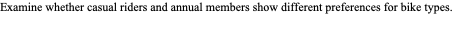
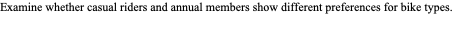
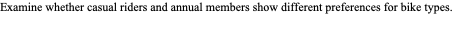
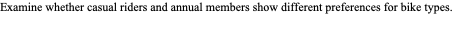

In [91]:
# Count the number of rides for each bike type and user type
bike_type_summary = (
    df.groupby(['rideable_type', 'member_casual'])
      .size()
      .reset_index(name='Ride Count')
)

# Create a grouped bar chart to compare bike type usage
fig = px.bar(
    bike_type_summary,
    x='rideable_type',
    y='Ride Count',
    color='member_casual',
    barmode='group',
    color_discrete_map=user_colors,
    title='Number of Rides by Bike Type and User Type',
    labels={
        'rideable_type': 'Bike Type',
        'Ride Count': 'Number of Rides',
        'member_casual': 'User Type'
    }
)

# Add space above the bars
fig.update_layout(
    yaxis_range=[
        0,
        bike_type_summary['Ride Count'].max() * 1.10
    ]
)

# Display the chart
fig.show()

#### Overall Bike Type Usage

* **Electric bikes** were used more frequently than classic bikes by both user groups.
* Annual members recorded more than **2.25 million electric bike rides**, compared with approximately **1.25 million classic bike rides**.
* Casual riders recorded approximately **1.3 million electric bike rides** and around **650k classic bike rides**.
* For both user groups, electric bike usage was approximately twice as high as classic bike usage.
* This indicates a strong preference for electric bikes across both casual riders and annual members.

#### Differences Between User Types

* Annual members recorded more rides than casual riders for **both bike types**.
* The difference was particularly large for electric bikes, with member usage substantially higher than casual usage.
* Despite the difference in total ride volume, the two user groups showed a **similar preference pattern**, with electric bikes being more commonly used than classic bikes.
* The consistent preference for electric bikes across both groups may reflect the convenience or accessibility of electric bikes, although the dataset does not provide information about the reasons for bike selection.

#### Key Business Insights

The bike type analysis highlights several important patterns:

* **Electric bikes are the most frequently used bike type** among both user groups.
* The preference for electric bikes is consistent among casual riders and annual members.
* Annual members have higher usage of both electric and classic bikes, reflecting their higher overall ride volume.
* Bike type appears to be an important factor in understanding how customers use the Cyclistic service.

#### Business Opportunities

1. **Fleet Management**

   Given the substantially higher usage of electric bikes, Cyclistic could monitor electric bike availability carefully and ensure sufficient supply at high-demand stations.

2. **Battery and Maintenance Planning**

   Higher electric bike usage may require greater attention to **battery availability, charging, maintenance, and fleet redistribution** to maintain service reliability.

3. **Membership Marketing**

   The high number of electric bike rides among casual riders provides an opportunity to examine whether electric bike users are more likely to become annual members.

### 5.8 Top Starting Stations

Identify the most frequently used starting stations and compare station usage between the two user types.

The number of rides was grouped by **starting station and user type**. The top 10 starting stations were identified based on ride volume and visualized using a bar chart.

This analysis helps identify **high-demand starting locations** and determine whether casual riders and annual members show different patterns in station usage.

The results can also provide insights into **station-level demand and bike availability**, which may support fleet management and operational planning.

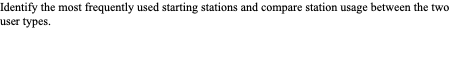
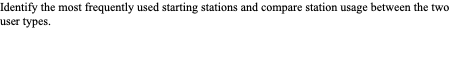
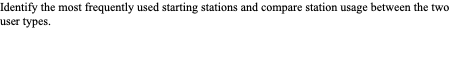
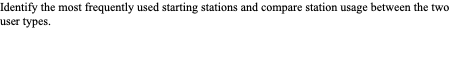

In [92]:
# Count the number of rides for each starting station and user type
station_summary = (
    df.groupby(['start_station_name', 'member_casual'])
      .size()
      .reset_index(name='Ride Count')
)

# Display the summary table
station_summary

,start_station_name,member_casual,Ride Count
0,2112 W Peterson Ave,casual,215
1,2112 W Peterson Ave,member,593
2,21st St & Pulaski Rd,casual,47
3,21st St & Pulaski Rd,member,44
4,63rd St Beach,casual,836
...,...,...,...
3551,Woodlawn Ave & Lake Park Ave,member,781
3552,Yates Blvd & 75th St,casual,34
3553,Yates Blvd & 75th St,member,76
3554,Yates Blvd & 93rd St,casual,36


In [93]:
# Calculate the total number of rides for each starting station
top_stations = (
    station_summary
    .groupby('start_station_name')['Ride Count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Display the top 10 starting stations
top_stations

start_station_name
Not Available                         1184669
Kingsbury St & Kinzie St                40587
DuSable Lake Shore Dr & Monroe St       39537
Navy Pier                               35099
Michigan Ave & Oak St                   35065
DuSable Lake Shore Dr & North Blvd      33760
Clinton St & Washington Blvd            30639
Streeter Dr & Grand Ave                 29977
Clark St & Elm St                       29878
Canal St & Madison St                   29170
Name: Ride Count, dtype: int64

`Not Available` does not represent a physical station, so it will be excluded from the station-level comparison. This prevents missing station information from being interpreted as an actual high-demand location.


In [94]:
# Remove records with unavailable starting station names
station_summary_valid = station_summary[
    station_summary['start_station_name'] != 'Not Available'
]

# Calculate the total number of rides for each valid starting station
top_stations = (
    station_summary_valid
    .groupby('start_station_name')['Ride Count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Display the top 10 physical starting stations
top_stations

start_station_name
Kingsbury St & Kinzie St              40587
DuSable Lake Shore Dr & Monroe St     39537
Navy Pier                             35099
Michigan Ave & Oak St                 35065
DuSable Lake Shore Dr & North Blvd    33760
Clinton St & Washington Blvd          30639
Streeter Dr & Grand Ave               29977
Clark St & Elm St                     29878
Canal St & Madison St                 29170
Clinton St & Madison St               28969
Name: Ride Count, dtype: int64

In [95]:
# Keep only the top 10 physical starting stations
top_station_data = station_summary_valid[
    station_summary_valid['start_station_name'].isin(top_stations.index)
]

# Store the station order based on total ride volume
station_order = top_stations.index.tolist()

# Display the filtered data
top_station_data

,start_station_name,member_casual,Ride Count
292,Canal St & Madison St,casual,7154
293,Canal St & Madison St,member,22016
402,Clark St & Elm St,casual,9036
403,Clark St & Elm St,member,20842
460,Clinton St & Madison St,casual,6896
461,Clinton St & Madison St,member,22073
468,Clinton St & Washington Blvd,casual,5077
469,Clinton St & Washington Blvd,member,25562
644,DuSable Lake Shore Dr & Monroe St,casual,31236
645,DuSable Lake Shore Dr & Monroe St,member,8301


In [96]:
# Create a grouped bar chart for the top 10 starting stations
fig = px.bar(
    top_station_data,
    x='start_station_name',
    y='Ride Count',
    color='member_casual',
    barmode='group',
    color_discrete_map=user_colors,
    category_orders={
        'start_station_name': station_order
    },
    title='Top 10 Starting Stations by User Type',
    labels={
        'start_station_name': 'Starting Station',
        'Ride Count': 'Number of Rides',
        'member_casual': 'User Type'
    }
)

# Display the chart
fig.show()

#### Key Findings

* Several stations recorded substantially higher ride volumes among **annual members** than casual riders.
* For example, **Kingsbury St & Kinzie St**, **Clinton St & Washington Blvd**, and **Canal St & Madison St** showed relatively higher member ride volumes.
* In contrast, stations such as **DuSable Lake Shore Dr & Monroe St**, **Streeter Dr & Grand Ave**, and **Navy Pier** showed relatively higher casual rider activity.
* These differences suggest that the user composition of starting stations varies across locations.
* Stations with higher member activity may be associated with more regular or routine travel patterns, while stations with higher casual activity may be more consistent with leisure or recreational usage. However, the dataset does not directly record the purpose of each ride, so these interpretations should be treated as potential patterns rather than confirmed trip purposes.

#### Business Insights

The station-level analysis shows that customer behavior varies across locations.

* High-demand stations may require careful attention to **bike availability and fleet rebalancing**.
* Stations with a relatively high proportion of casual riders may provide opportunities for further **membership conversion analysis**.

#### Business Opportunities

1. **Location-Based Membership Marketing**

   Stations with relatively high casual rider activity could be investigated as potential locations for membership marketing. Further analysis could identify whether casual riders at these stations also show frequent usage or other characteristics associated with annual members.

2. **Station and Fleet Management**

   High-demand stations could receive additional attention for bike availability, redistribution, and capacity planning, particularly during periods of high demand.

3. **Segment-Specific Analysis**

   Cyclistic could combine station usage with **user type, time, ride duration, distance, and bike type** to identify different customer segments and better understand their riding behavior.

## 6. Geographic Analysis

Geographic analysis was conducted to examine the **spatial distribution of Cyclistic rides** and identify potential differences in riding patterns between **annual members** and **casual riders**.

The analysis uses the **latitude and longitude coordinates** of ride start and end locations to visualize where rides take place across the Cyclistic service area.

Separate visualizations were created for annual members and casual riders. Each ride is represented by a line connecting its **starting location** to its **ending location**.

### 6.1 Geographic Distribution of Member Rides

The geographic distribution of rides made by **annual members** was visualized using the latitude and longitude coordinates of the starting and ending locations.

Because the dataset contains millions of rides, a random sample of **5,000 rides from each user type** was selected for the geographic visualization.

Sampling reduces visual clutter and improves plotting performance while still providing a representative view of the overall geographic distribution of rides.


This visualization provides an overview of the **spatial concentration and distribution of member rides** and helps identify whether member trips tend to occur within concentrated areas or across a wider geographic range.



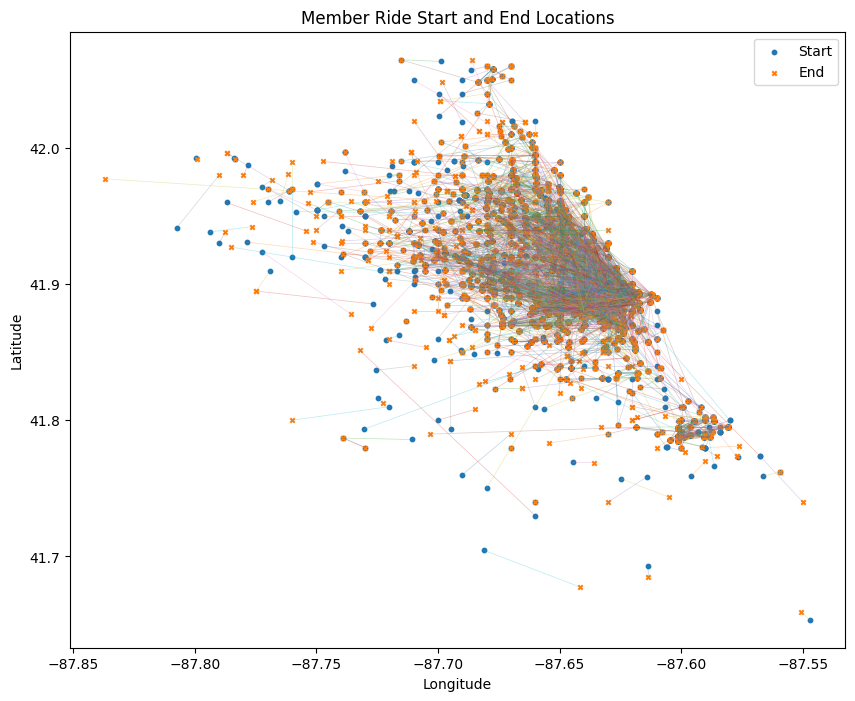

In [107]:
# Randomly sample rides for each user type
geo_sample = (
    df.groupby('member_casual', group_keys=False)
      .apply(
          lambda x: x.sample(
              n=min(5000, len(x)),
              random_state=42
          )
      )
)


member_data = geo_sample[
    geo_sample['member_casual'] == 'member'
]

plt.figure(figsize=(10, 8))

# Draw a line from the start location to the end location for each ride
for _, row in member_data.iterrows():
    plt.plot(
        [row['start_lng'], row['end_lng']],
        [row['start_lat'], row['end_lat']],
        alpha=0.3,
        linewidth=0.5
    )

# Show start locations
plt.scatter(
    member_data['start_lng'],
    member_data['start_lat'],
    label='Start',
    marker='o',
    s=10
)

# Show end locations
plt.scatter(
    member_data['end_lng'],
    member_data['end_lat'],
    label='End',
    marker='x',
    s=10
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Member Ride Start and End Locations')
plt.legend()

plt.show()

The scatter plot shows the geographic distribution of **ride start and end locations for annual members**. Blue circles represent starting locations, while orange crosses represent ending locations. Each ride is also represented by a line connecting its starting and ending locations.

#### Spatial Distribution

* Most member ride start and end locations are concentrated within a relatively small geographic area around **central Chicago**.
* The highest density of locations appears approximately between **41.85–42.00 latitude** and **-87.68–-87.60 longitude**.
* Start and end locations are highly concentrated and frequently overlap within the core service area.
* Only a relatively small number of rides extend to locations farther from this high-density area.

#### Riding Pattern Insights

The concentration of member rides within the central service area indicates that annual members make frequent use of the bike-share network in a relatively concentrated geographic area.

The dense and overlapping start and end locations also suggest that many member trips are relatively short and occur between locations within the core service area.

These spatial patterns are consistent with **regular and repeated use of the bike-share network**, although the dataset does not directly identify the purpose of individual trips, such as commuting, recreation, or sightseeing.

#### Business and Operational Insights

1. **High-Demand Area Management**

   The concentration of member rides within the central service area suggests that these locations are important areas for bike availability and fleet management.

2. **Bike Redistribution**

   Areas with consistently high concentrations of starting and ending locations could receive greater attention during bike redistribution and operational planning.

3. **Member Usage Patterns**

   The concentrated geographic distribution of member rides can be considered together with the earlier findings on **weekday usage, peak-hour activity, ride duration, and distance** to better understand regular member riding behavior.


### 6.2 Geographic Distribution of Casual Rider Rides

The geographic distribution of rides made by **casual riders** was visualized using the latitude and longitude coordinates of the starting and ending locations.

A sample of casual rider trips was used to create the visualization. Each ride is represented by a line connecting its **starting location** to its **ending location**. Start locations are shown as circles, while end locations are shown as crosses.

This visualization provides an overview of the **spatial distribution and geographic extent of casual rider trips** and allows their riding patterns to be compared with those of annual members.


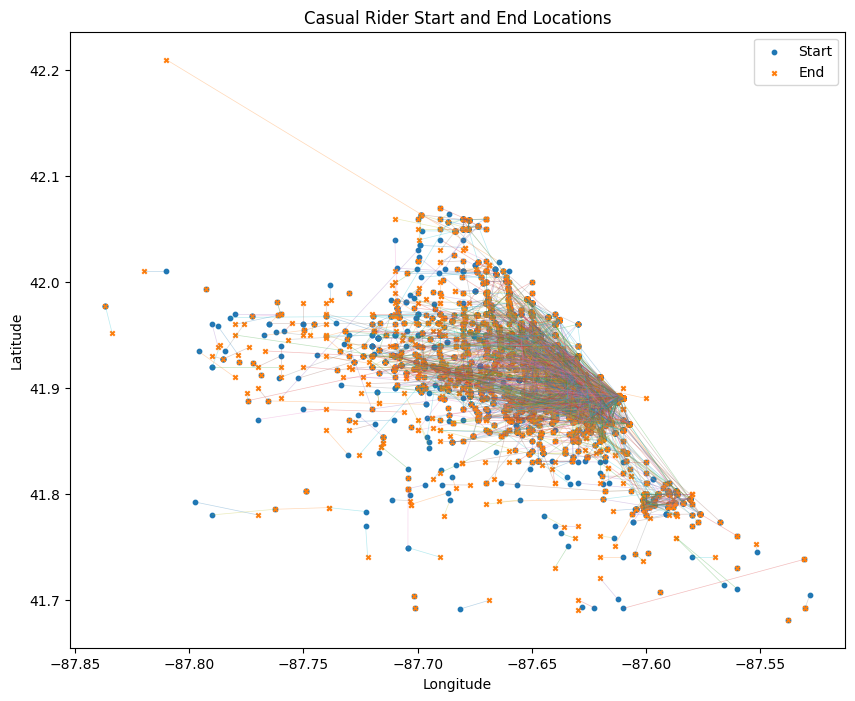

In [108]:
casual_data = geo_sample[
    geo_sample['member_casual'] == 'casual'
]

plt.figure(figsize=(10, 8))

# Draw a line from the start location to the end location for each ride
for _, row in casual_data.iterrows():
    plt.plot(
        [row['start_lng'], row['end_lng']],
        [row['start_lat'], row['end_lat']],
        alpha=0.3,
        linewidth=0.5
    )

# Show start locations
plt.scatter(
    casual_data['start_lng'],
    casual_data['start_lat'],
    label='Start',
    marker='o',
    s=10
)

# Show end locations
plt.scatter(
    casual_data['end_lng'],
    casual_data['end_lat'],
    label='End',
    marker='x',
    s=10
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Casual Rider Start and End Locations')
plt.legend()

plt.show()

The scatter plot shows the geographic distribution of **ride start and end locations for casual riders**. Blue circles represent starting locations, while orange crosses represent ending locations. Each ride is also represented by a line connecting its starting and ending locations.

#### Spatial Distribution

* Casual rider activity is concentrated around the **central Chicago and lakeside areas**.
* A relatively high density of start and end locations can be observed around the area between approximately **41.85–41.95 latitude** and **-87.65–-87.60 longitude**.
* Compared with the member visualization, casual rider locations appear to have a **broader spatial distribution**, with more locations extending beyond the main high-density area.
* Several rides also show relatively longer connections between starting and ending locations, indicating greater variation in the spatial extent of casual rider trips.

#### Riding Pattern Insights

The broader geographic distribution of casual rides suggests that casual riders use the bike-share network across a wider range of locations.

The presence of rides connecting more distant locations may indicate greater variation in trip patterns among casual riders. These patterns may be consistent with more flexible or recreational usage, although the dataset does not directly record the purpose of each ride.

#### Comparison with Annual Members

The geographic visualizations show some differences between the two user groups:

* **Annual members** show a more concentrated distribution of ride locations within the central service area.
* **Casual riders** show a relatively broader spatial distribution, with more rides extending beyond the main concentration of locations.
* Casual rider trips also appear to contain greater variation in the geographic distance between start and end locations.

#### Business and Operational Insights

1. **Demand Planning**

   Areas with relatively high concentrations of casual rider activity could be considered when planning bike availability and fleet redistribution.

2. **Seasonal and Weekend Operations**

   The geographic patterns can be combined with the earlier findings on **weekend usage and seasonal demand** to identify locations and periods that may require additional operational attention.

3. **Location-Based Marketing**

   Areas with relatively high casual rider activity could be considered for targeted membership marketing. Further analysis of ride frequency, duration, distance, and time of use could help identify casual riders with higher potential for membership conversion.

## 7. Key Findings

The analysis identified several key differences between annual members and casual riders:

* **Annual members** showed higher and more consistent usage, particularly on weekdays and during peak hours.
* **Casual riders** were more active on weekends and during warmer months.
* Annual members generally took **shorter rides**, while casual riders had a relatively higher share of longer rides.
* Most rides covered **short distances**, with annual members particularly concentrated in the 1–2 km range.
* **Electric bikes** were the most commonly used bike type for both user groups.
* Member rides were more geographically concentrated, while casual rides showed a relatively broader spatial distribution.

## 8. Business Recommendations

Based on the findings, Cyclistic could consider the following strategies:

* **Target frequent casual riders** with personalized membership offers.
* **Increase seasonal and weekend marketing** when casual rider activity is higher.
* **Use location-based marketing** at stations with relatively high casual rider activity.
* **Improve bike and station planning** based on seasonal, hourly, and geographic demand patterns.
* **Track conversion rates and membership growth** to evaluate the effectiveness of marketing campaigns.
